# 0. Giới thiệu

Notebook này dùng để thuyết trình ngắn về **RepLKNet (2022)** – một Large Kernel CNN – và so sánh với VGG-16, một CNN thuần truyền thống dạng tuần tự dùng nhiều kernel nhỏ.

Mục tiêu là trả lời ba câu hỏi **WHAT – WHY – HOW**, sau đó chạy cùng một ảnh qua hai model, đo một số chỉ số và minh họa Effective Receptive Field (ERF). Repository chính thức được giữ nguyên trong `RepLKNet-pytorch/`; code bổ sung nằm ở `src/replknet_demo.py`.

> Cách chạy: mở Jupyter tại thư mục project và chạy các cell từ trên xuống. Nếu chưa có GPU hoặc checkpoint, notebook vẫn chạy phần lý thuyết và những demo nhẹ, đồng thời in rõ phần nào bị bỏ qua.

## Chuẩn bị đường dẫn project

Cell này tìm thư mục project từ vị trí hiện tại hoặc các thư mục cha. Nhờ vậy notebook có thể được mở từ root hoặc từ thư mục `notebooks/`. Kết quả mong đợi là đường dẫn tới project và phiên bản Python đang dùng.

In [1]:
import platform
import sys
from pathlib import Path

print(f"Python: {platform.python_version()}")
print(f"Executable: {sys.executable}")

try:
    PROJECT_ROOT = Path.cwd().resolve()
    for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
        if (candidate / 'RepLKNet-pytorch' / 'replknet.py').exists():
            PROJECT_ROOT = candidate
            break
    if not (PROJECT_ROOT / 'RepLKNet-pytorch' / 'replknet.py').exists():
        raise FileNotFoundError
    print(f"Project root: {PROJECT_ROOT}")
except FileNotFoundError:
    PROJECT_ROOT = None
    print('Không tìm thấy project root. Hãy mở notebook trong thư mục RepLKNet.')

Python: 3.12.10
Executable: E:\NCKH\DL\CNN\RepLKNet\.venv\Scripts\python.exe
Project root: E:\NCKH\DL\CNN\RepLKNet


# 1. Chuẩn bị môi trường và kiểm tra thư viện

Cell này kiểm tra những thư viện cần cho demo. Không import trực tiếp repository ở đây vì repo chính thức cần `timm`; việc import helper sẽ được thực hiện sau khi biết rõ PyTorch có sẵn hay không. Nếu thiếu package, cell chỉ in hướng dẫn thay vì làm notebook dừng ngay.

In [2]:
TORCH_AVAILABLE = False
MATPLOTLIB_AVAILABLE = False
DEMO_UTILS_AVAILABLE = False

try:
    import torch
    import torchvision
    TORCH_AVAILABLE = True
    print(f'PyTorch: {torch.__version__}')
    print(f'torchvision: {torchvision.__version__}')
except Exception as exc:
    print(f'Chưa sẵn sàng PyTorch/torchvision: {exc}')
    print('Cài dependencies bằng: python -m pip install -r requirements.txt')

try:
    import matplotlib.pyplot as plt
    MATPLOTLIB_AVAILABLE = True
except Exception as exc:
    print(f'Chưa có matplotlib: {exc}')

if PROJECT_ROOT is not None:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))
    try:
        from replknet_demo import (
            benchmark_model, build_replknet, build_tiny_replknet_for_reparam_check,
            compute_erf_map, device_report, find_or_create_sample_image,
            load_checkpoint_flexible, load_image_tensor, load_imagenet_labels,
            model_stats, predict_topk, prediction_table_html,
            download_official_checkpoint, save_numpy,
        )
        DEMO_UTILS_AVAILABLE = True
        print('Đã import wrapper/helper của project.')
    except Exception as exc:
        print(f'Không import được helper: {exc}')

PyTorch: 2.11.0+cu128
torchvision: 0.26.0+cu128


Đã import wrapper/helper của project.


## Kiểm tra GPU NVIDIA

Cell này kiểm tra `torch.cuda.is_available()`, tên GPU, CUDA version và VRAM. `device` được chọn tự động: dùng `cuda` khi có GPU, ngược lại dùng `cpu`. Các kết quả benchmark sau đó phải được đọc trong bối cảnh phần cứng này.

In [3]:
if TORCH_AVAILABLE:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Device: {device}')
    print(f'CUDA available: {torch.cuda.is_available()}')
    print(f'CUDA version trong PyTorch: {torch.version.cuda or "Không có"}')
    if torch.cuda.is_available():
        gpu_index = torch.cuda.current_device()
        gpu_name = torch.cuda.get_device_name(gpu_index)
        vram_gb = torch.cuda.get_device_properties(gpu_index).total_memory / (1024 ** 3)
        print(f'GPU: {gpu_name}')
        print(f'VRAM: {vram_gb:.2f} GB')
    else:
        print('Không tìm thấy CUDA/GPU NVIDIA; notebook sẽ dùng CPU. Các cell model lớn có thể rất chậm.')
else:
    device = None
    print('Chưa thể chọn device vì PyTorch chưa được cài.')

Device: cuda
CUDA available: True
CUDA version trong PyTorch: 12.8
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM: 6.00 GB


# 2. RepLKNet là gì? – WHAT

**RepLKNet** là một CNN được giới thiệu trong paper CVPR 2022 *Scaling Up Your Kernels to 31×31: Revisiting Large Kernel Design in CNNs*. Ý tưởng chính là đưa convolution kernel rất lớn vào các stage quan trọng của CNN, nổi bật là 31×31, để một vị trí feature có thể kết hợp thông tin từ vùng rộng hơn.

Điểm cần nhớ khi thuyết trình:

- RepLKNet vẫn là CNN, không phải một họ mô hình hoàn toàn khác.
- Khác biệt nổi bật so với **Traditional/Small-Kernel CNN** là kích thước kernel và cách thiết kế block.
- Trong implementation chính thức, các stage dùng large kernel giảm dần `[31, 29, 27, 13]` ở RepLKNet-31B.
- Tên “Rep” gợi đến **structural re-parameterization**: lúc training có thể dùng nhiều nhánh, lúc inference gộp thành một convolution lớn.

## Sơ đồ ý tưởng

Ảnh đi qua stem, nhiều RepLK block và transition giữa các stage, sau đó global pooling và classifier. Large kernel không có nghĩa là mọi layer đều dùng kernel 31×31; thiết kế dùng kernel lớn ở những vị trí có ích và giảm kích thước feature map theo stage.

```text
Image → Stem → Stage 1 → Transition → Stage 2 → Transition
      → Stage 3 → Transition → Stage 4 → Global Pooling → Classifier
```

# 3. Vì sao cần RepLKNet? – WHY

CNN truyền thống thường dùng kernel nhỏ như 3×3. Một kernel 3×3 nhìn trực tiếp một vùng rất cục bộ; muốn lấy context rộng hơn, ta phải xếp nhiều layer. Khi xếp sâu, receptive field lý thuyết mở rộng nhưng đường truyền thông tin dài hơn và mô hình phải học qua nhiều bước.

**Receptive Field (vùng quan sát)** là vùng ảnh mà một neuron ở feature map có thể “nhìn thấy”. Hãy hình dung một pixel ở layer đầu chỉ nhìn một ô nhỏ; qua nhiều layer, ô đó lớn dần. Large kernel mở rộng vùng nhìn ngay trong một phép convolution.

Large kernel có thể hữu ích khi quyết định cần kết hợp các phần ở xa nhau: hình dạng toàn vật thể, quan hệ giữa nền và vật thể, hoặc context không nằm cạnh nhau. Đổi lại, kernel lớn có nhiều phép tính và có thể tốn memory; vì vậy tốc độ thực tế phụ thuộc implementation, GPU và cách tối ưu. RepLKNet cũng không tự động thắng mọi bài toán.

## Minh họa trực quan 3×3, 7×7 và 31×31

Cell này vẽ một lưới ảnh giả lập và tô vùng mà kernel phủ lên khi đặt tại tâm. Đây là hình minh họa hình học, không phải output của model; kết quả mong đợi là vùng 31×31 lớn hơn rõ rệt so với 3×3 và 7×7.

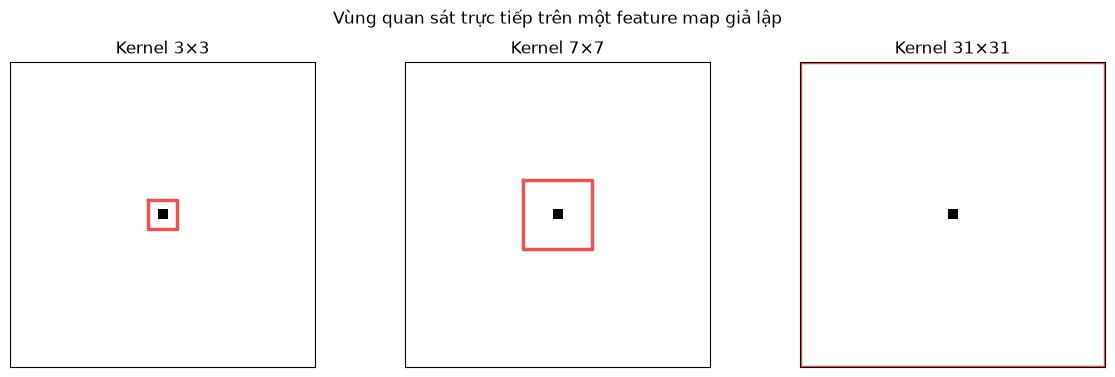

In [4]:
if MATPLOTLIB_AVAILABLE:
    import numpy as np
    canvas = np.zeros((31, 31))
    canvas[15, 15] = 1
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
    for ax, kernel_size in zip(axes, (3, 7, 31)):
        ax.imshow(canvas, cmap='Greys', vmin=0, vmax=1)
        start = (31 - kernel_size) // 2
        end = start + kernel_size - 1
        ax.plot([start - 0.5, end + 0.5, end + 0.5, start - 0.5, start - 0.5],
                [start - 0.5, start - 0.5, end + 0.5, end + 0.5, start - 0.5],
                color='#e45756', linewidth=2.5)
        ax.set_title(f'Kernel {kernel_size}×{kernel_size}')
        ax.set_xticks([])
        ax.set_yticks([])
    fig.suptitle('Vùng quan sát trực tiếp trên một feature map giả lập')
    plt.tight_layout()
    plt.show()
else:
    print('Bỏ qua hình vẽ vì matplotlib chưa sẵn sàng.')

# 4. RepLKNet vs CNN truyền thống

VGG-16 được chọn làm baseline vì là CNN thuần dạng tuần tự: chủ yếu dùng convolution 3×3, ReLU và pooling, không có shortcut/residual. Bảng dưới đây so sánh ở mức kiến trúc; số đo latency thực tế sẽ được chạy ở phần 9. “Receptive field rộng hơn” không đồng nghĩa mọi neuron đều tự động dùng toàn bộ ảnh, vì còn phụ thuộc stride, stage và trọng số học được.
Lưu ý: VGG-16 có khoảng 138M tham số còn RepLKNet-31B khoảng 79M, nên đây là so sánh khác biệt kiến trúc chứ không phải so sánh cùng capacity.

| Tiêu chí | VGG-16 (CNN thuần) | RepLKNet-31B |
|---|---|---|
| Loại kernel | Chủ yếu 3×3; không có shortcut/residual | Depthwise large kernel 31×31, 29×29, 27×27, 13×13; có nhánh 5×5 lúc training |
| Receptive field | Tăng dần nhờ xếp nhiều convolution và pooling | Mở rộng mạnh hơn tại block large-kernel |
| Global context | Tích lũy qua nhiều layer tuần tự | Thu nhận context rộng hơn trong mỗi large-kernel block |
| Kiến trúc | Chuỗi convolution–ReLU–pooling và classifier | Stem, các RepLK stage, transition, global pooling |
| Parameters | Khoảng 138M (VGG-16 pretrained) | Khoảng 79M theo model card chính thức |
| Inference | Classifier lớn nên thường nặng về tham số/tính toán | Có thể tốn hơn; phụ thuộc tối ưu large-kernel và GPU |
| Ưu điểm | CNN thuần, dễ giải thích vai trò của kernel nhỏ | Context rộng, large-kernel CNN hiệu quả ở quy mô lớn |
| Hạn chế | Nhiều parameter/tính toán, không có residual | Nhiều parameter/tính toán hơn, checkpoint và kernel lớn nặng hơn |

# 5. RepLKNet hoạt động thế nào? – HOW

Một **RepLK block** trong implementation chính thức có thể đọc như sau:

```text
x → BN → 1×1 pointwise → large-kernel depthwise conv → ReLU → 1×1 → cộng residual
                                      ↑
                       small-kernel branch (khi training)
```

Trong training, large-kernel branch và small-kernel branch đều có Conv + BatchNorm. Nhánh nhỏ giúp tối ưu dễ hơn và cung cấp đường học bổ sung. Sau khi học xong, BatchNorm được fuse vào convolution, kernel nhỏ được đặt vào phần trung tâm của kernel lớn, rồi hai nhánh được cộng lại. Đây là **structural re-parameterization**: nhiều nhánh lúc học → một convolution tương đương lúc inference.

Ví dụ đời thường: lúc học có thể dùng nhiều bản nháp để tìm cách giải tốt; lúc thi chỉ giữ lại công thức đã gộp để chạy gọn hơn. Việc gộp này không phải là train lại model.

## Kiểm tra structural re-parameterization bằng model nhỏ

Cell này dùng chính class `RepLKNet` trong repository chính thức nhưng với channel/layer nhỏ để chạy nhanh. Ta tính output trước và sau `structural_reparam()` trên cùng input ở chế độ eval. Kết quả mong đợi là sai khác rất nhỏ, do sai số số thực; đây là kiểm tra equivalence của phép gộp chứ không phải benchmark accuracy.

In [5]:
if TORCH_AVAILABLE and DEMO_UTILS_AVAILABLE:
    torch.manual_seed(7)
    tiny_model = build_tiny_replknet_for_reparam_check(PROJECT_ROOT).to(device).eval()
    tiny_input = torch.randn(1, 3, 32, 32, device=device)
    with torch.inference_mode():
        output_before = tiny_model(tiny_input)
    tiny_model.structural_reparam()
    with torch.inference_mode():
        output_after = tiny_model(tiny_input)
    max_difference = (output_before - output_after).abs().max().item()
    print(f'Sai khác tuyệt đối lớn nhất trước/sau merge: {max_difference:.3e}')
    print('Sai khác nhỏ cho thấy các nhánh đã được gộp tương đương trong sai số số thực.')
else:
    print('Bỏ qua kiểm tra vì PyTorch/helper chưa sẵn sàng.')

E:\NCKH\DL\CNN\RepLKNet\.venv\Lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


drop path: Identity()
drop path: Identity()


Sai khác tuyệt đối lớn nhất trước/sau merge: 0.000e+00
Sai khác nhỏ cho thấy các nhánh đã được gộp tương đương trong sai số số thực.


# 6. Load RepLKNet pretrained

Notebook ưu tiên **RepLKNet-31B ImageNet-1K 224×224** vì đây là lựa chọn lớn nhưng vẫn thực tế hơn 31L/XL cho demo sinh viên. Checkpoint chính thức cần đặt tại `weights/RepLKNet-31B_ImageNet-1K_224.pth`. Wrapper đọc được checkpoint có key `model`, `state_dict` hoặc tiền tố `module.`; sau khi load, model được chuyển sang `eval()` và gọi `structural_reparam()` để chuẩn bị inference.

`AUTO_DOWNLOAD_CHECKPOINT` mặc định là `False` để chạy notebook không tự tải file lớn. Nếu muốn tải tự động và đã cài `gdown`, đổi thành `True`. Nếu file chưa có, cell vẫn tạo model để kiểm tra pipeline nhưng phải đọc cảnh báo: trọng số khởi tạo không cho prediction ImageNet có ý nghĩa.

In [6]:
MODEL_NAME = 'RepLKNet-31B'
IMAGE_SIZE = 224
CHECKPOINT_NAME = 'RepLKNet-31B_ImageNet-1K_224.pth'
CHECKPOINT_PATH = PROJECT_ROOT / 'weights' / CHECKPOINT_NAME if PROJECT_ROOT else None
AUTO_DOWNLOAD_CHECKPOINT = False

replknet_model = None
replknet_status = {'checkpoint_loaded': False}
replknet_stats = None

if TORCH_AVAILABLE and DEMO_UTILS_AVAILABLE:
    if AUTO_DOWNLOAD_CHECKPOINT and CHECKPOINT_PATH is not None and not CHECKPOINT_PATH.exists():
        download_official_checkpoint(CHECKPOINT_PATH, CHECKPOINT_NAME)
    replknet_model, replknet_status = build_replknet(
        PROJECT_ROOT, model_name=MODEL_NAME, checkpoint_path=CHECKPOINT_PATH,
        device=device, merge_for_inference=True
    )
    replknet_stats = model_stats(replknet_model)
    print(f"Model: {MODEL_NAME}")
    print(f"Parameters: {replknet_stats['parameters']:,}")
    print(f"Model size ước tính: {replknet_stats['model_size_mb']:.2f} MB")
    print(f"Checkpoint loaded: {replknet_status['checkpoint_loaded']}")
else:
    print('Bỏ qua RepLKNet vì môi trường chưa đủ dependencies.')

drop path: Identity()
drop path: Identity()
drop path: Identity()
drop path: Identity()
drop path: Identity()
drop path: Identity()
drop path: Identity()
drop path: Identity()


drop path: Identity()


drop path: Identity()
drop path: Identity()
drop path: Identity()
drop path: Identity()
drop path: Identity()
drop path: Identity()
drop path: Identity()
drop path: Identity()


drop path: Identity()
drop path: Identity()
drop path: Identity()
drop path: Identity()
drop path: Identity()
drop path: Identity()


drop path: Identity()


Đã load checkpoint: RepLKNet-31B_ImageNet-1K_224.pth


Model: RepLKNet-31B
Parameters: 79,527,272
Model size ước tính: 304.24 MB
Checkpoint loaded: True


# 7. Load CNN baseline – VGG-16

VGG-16 là baseline CNN thuần truyền thống. Cell dùng API mới của `torchvision` (`VGG16_Weights.DEFAULT`) để tránh cảnh báo `pretrained=True` đã cũ, rồi đặt model ở `eval()` và cùng `device` với RepLKNet. Nếu torchvision không tải được checkpoint, cell tạo VGG-16 với `weights=None` và ghi rõ trạng thái.

In [7]:
traditional_cnn_model = None
traditional_cnn_status = {'checkpoint_loaded': False}
traditional_cnn_stats = None

if TORCH_AVAILABLE:
    from torchvision.models import VGG16_Weights, vgg16
    try:
        traditional_cnn_model = vgg16(weights=VGG16_Weights.DEFAULT)
        traditional_cnn_status['checkpoint_loaded'] = True
        print('Đã load VGG-16 ImageNet pretrained.')
    except Exception as exc:
        print(f'Không tải được VGG-16 pretrained: {exc}')
        print('Tiếp tục với VGG-16 trọng số khởi tạo để kiểm tra pipeline.')
        traditional_cnn_model = vgg16(weights=None)
    traditional_cnn_model = traditional_cnn_model.to(device).eval()
    traditional_cnn_stats = model_stats(traditional_cnn_model)
    print(f"Parameters: {traditional_cnn_stats['parameters']:,}")
else:
    print('Bỏ qua VGG-16 vì PyTorch chưa sẵn sàng.')

Đã load VGG-16 ImageNet pretrained.


Parameters: 138,357,544


# 8. Demo inference trên cùng một ảnh

Cell này chọn ảnh đầu tiên trong `images/`. Nếu chưa có ảnh, helper tạo một ảnh hình học để kiểm tra pipeline. Ảnh được resize/crop về 224×224 và normalize theo ImageNet. Sau đó cùng một tensor đi qua VGG-16 và RepLKNet trong `torch.inference_mode()`. Bảng hiển thị Top-1, confidence, Top-5 và thời gian của từng lần chạy.

Nếu dùng ảnh hình học tự tạo hoặc model chưa có checkpoint, hãy xem prediction như kiểm tra kỹ thuật; không dùng nó để kết luận model nhận dạng đúng.

Ảnh đang dùng: images\demo_shapes.png


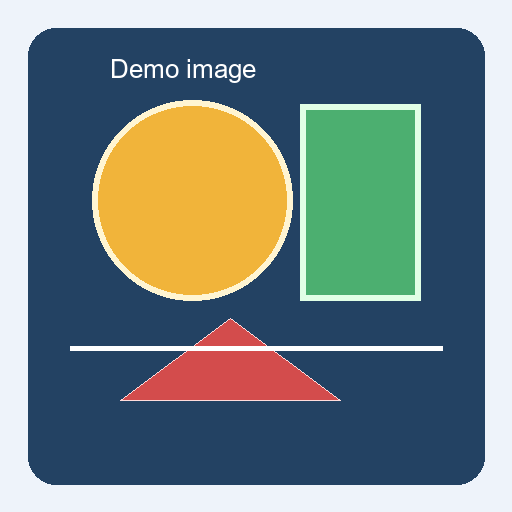

Model,Top-1,Confidence,Top-5,Inference time (ms)
VGG-16 (CNN thuần),analog clock,13.40%,analog clock (13.40%)envelope (10.97%)face powder (10.05%)Band Aid (8.78%)binder (7.60%),406.94
RepLKNet-31B,shield,38.03%,shield (38.03%)puck (18.62%)jersey (1.26%)bathing cap (1.08%)web site (0.66%),185.72


Đã lưu: results\predictions\predictions.json


In [8]:
import json
from IPython.display import HTML, display

prediction_results = []
sample_path = None
image_tensor = None

if TORCH_AVAILABLE and DEMO_UTILS_AVAILABLE and PROJECT_ROOT is not None:
    sample_path = find_or_create_sample_image(PROJECT_ROOT / 'images')
    original_image, image_tensor = load_image_tensor(sample_path, IMAGE_SIZE)
    print(f'Ảnh đang dùng: {sample_path.relative_to(PROJECT_ROOT)}')
    display(original_image)
    labels = load_imagenet_labels(PROJECT_ROOT / 'results' / 'imagenet_classes.txt')
    for model_label, model in [('VGG-16 (CNN thuần)', traditional_cnn_model), (MODEL_NAME, replknet_model)]:
        if model is None:
            continue
        prediction = predict_topk(model, image_tensor, labels, device=device, k=5)
        prediction_results.append({'model': model_label, 'prediction': prediction})
    if prediction_results:
        display(HTML(prediction_table_html(prediction_results)))
        prediction_path = PROJECT_ROOT / 'results' / 'predictions' / 'predictions.json'
        prediction_path.write_text(json.dumps(prediction_results, ensure_ascii=False, indent=2), encoding='utf-8')
        print(f'Đã lưu: {prediction_path.relative_to(PROJECT_ROOT)}')
else:
    print('Bỏ qua inference vì môi trường chưa đủ dependencies/model.')

# 9. Benchmark RepLKNet vs VGG-16

Benchmark phải có warm-up vì lần chạy đầu thường bao gồm khởi tạo kernel và cache. Cell chạy nhiều lần, lấy mean/std; với GPU, gọi `torch.cuda.synchronize()` trước khi đọc đồng hồ để không đo thiếu thời gian do CUDA chạy bất đồng bộ. `gpu_memory_mb` là peak allocated của PyTorch trong cell này, không phải toàn bộ VRAM đang dùng.

Đây là số đo phụ thuộc máy: GPU, driver, phiên bản PyTorch, input size, batch size và large-kernel implementation đều ảnh hưởng kết quả.

In [9]:
benchmark_results = []
if TORCH_AVAILABLE and DEMO_UTILS_AVAILABLE and image_tensor is not None:
    repeats = 20 if device.type == 'cuda' else 3
    warmup = 5 if device.type == 'cuda' else 1
    for model_label, model in [('VGG-16 (CNN thuần)', traditional_cnn_model), (MODEL_NAME, replknet_model)]:
        if model is None:
            continue
        stats = model_stats(model)
        timing = benchmark_model(model, image_tensor, warmup=warmup, repeats=repeats)
        benchmark_results.append({'model': model_label, **stats, **timing})
    if benchmark_results:
        headers = ['Model', 'Parameters', 'Size (MB)', 'Mean (ms)', 'Std (ms)', 'GPU memory (MB)']
        rows_html = []
        for row in benchmark_results:
            rows_html.append(
                '<tr>' + ''.join([
                    f"<td>{row['model']}</td>",
                    f"<td>{row['parameters']:,}</td>",
                    f"<td>{row['model_size_mb']:.2f}</td>",
                    f"<td>{row['mean_ms']:.3f}</td>",
                    f"<td>{row['std_ms']:.3f}</td>",
                    f"<td>{row['gpu_memory_mb'] if row['gpu_memory_mb'] is not None else 'N/A'}</td>",
                ]) + '</tr>'
            )
        table = '<table><thead><tr>' + ''.join(f'<th>{h}</th>' for h in headers) + '</tr></thead><tbody>' + ''.join(rows_html) + '</tbody></table>'
        display(HTML(table))
        benchmark_path = PROJECT_ROOT / 'results' / 'comparison' / 'benchmark.json'
        benchmark_path.write_text(json.dumps(benchmark_results, ensure_ascii=False, indent=2), encoding='utf-8')
        print(f'Đã lưu: {benchmark_path.relative_to(PROJECT_ROOT)}')
else:
    print('Bỏ qua benchmark vì chưa có input/model.')

Model,Parameters,Size (MB),Mean (ms),Std (ms),GPU memory (MB)
VGG-16 (CNN thuần),"138,357,544",527.79,14.378,3.037,867.5
RepLKNet-31B,"79,527,272",304.24,45.476,10.550,860.99


Đã lưu: results\comparison\benchmark.json


# 10. Demo Effective Receptive Field (ERF)

Repository chính thức có script ERF tại `RepLKNet-pytorch/erf/visualize_erf.py`. Script đó dùng dataset ImageNet và tích lũy gradient trên nhiều ảnh lớn để tái tạo phân tích của paper. Ở đây ta làm bản demo ngắn gọn trên **một ảnh 224×224**: lấy feature map cuối, chọn vị trí trung tâm, backprop về input và cộng gradient dương theo ba kênh.

Bản đồ sáng hơn nghĩa là pixel đó có contribution gradient lớn hơn đối với vị trí feature được chọn. Đây là minh họa trực quan phụ thuộc input, checkpoint và cách chọn feature; không nên xem là bằng chứng tuyệt đối rằng mọi RepLKNet luôn có ERF lớn hơn.

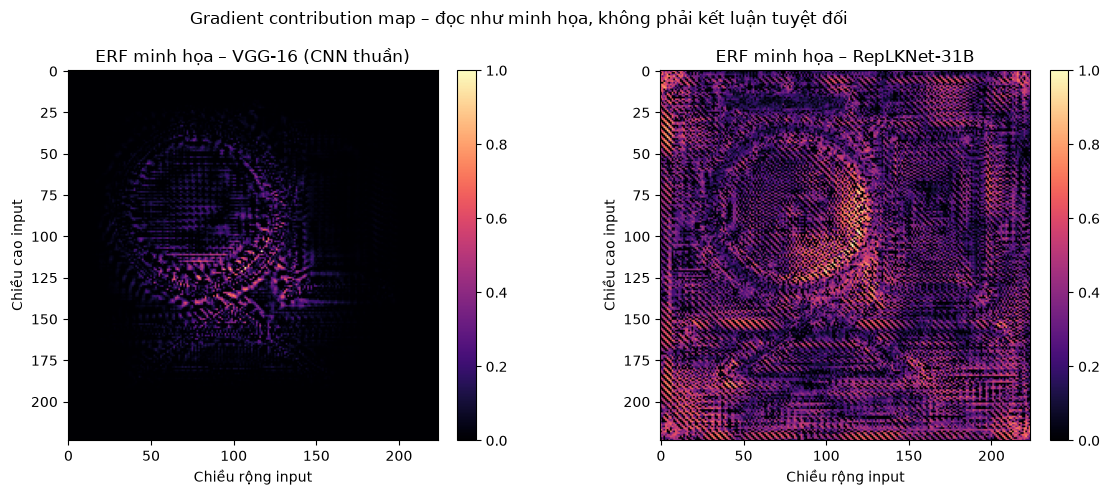

Đã lưu hình ERF: results\erf\erf_comparison.png


In [10]:
import numpy as np

erf_results = {}
if TORCH_AVAILABLE and DEMO_UTILS_AVAILABLE and image_tensor is not None:
    for model_label, model, model_kind in [
        ('VGG-16 (CNN thuần)', traditional_cnn_model, 'vgg'),
        (MODEL_NAME, replknet_model, 'replknet'),
    ]:
        if model is None:
            continue
        try:
            erf_map = compute_erf_map(model, image_tensor, model_kind=model_kind)
            erf_results[model_label] = erf_map
            safe_name = {
                'VGG-16 (CNN thuần)': 'vgg_16_cnn_thuan',
                MODEL_NAME: MODEL_NAME.lower().replace('-', '_'),
            }.get(model_label, model_label.lower().replace('-', '_'))
            save_numpy(PROJECT_ROOT / 'results' / 'erf' / f'{safe_name}_erf.npy', erf_map)
        except Exception as exc:
            print(f'Không tính được ERF cho {model_label}: {exc}')
    if erf_results and MATPLOTLIB_AVAILABLE:
        fig, axes = plt.subplots(1, len(erf_results), figsize=(6 * len(erf_results), 5))
        axes = np.atleast_1d(axes)
        for ax, (model_label, erf_map) in zip(axes, erf_results.items()):
            im = ax.imshow(erf_map, cmap='magma', vmin=0, vmax=1)
            ax.set_title(f'ERF minh họa – {model_label}')
            ax.set_xlabel('Chiều rộng input')
            ax.set_ylabel('Chiều cao input')
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        fig.suptitle('Gradient contribution map – đọc như minh họa, không phải kết luận tuyệt đối')
        plt.tight_layout()
        erf_png = PROJECT_ROOT / 'results' / 'erf' / 'erf_comparison.png'
        fig.savefig(erf_png, dpi=160, bbox_inches='tight')
        plt.show()
        print(f'Đã lưu hình ERF: {erf_png.relative_to(PROJECT_ROOT)}')
    elif not erf_results:
        print('Không có ERF để vẽ.')
else:
    print('Bỏ qua ERF vì chưa có input/model.')

# 11. Tổng kết kết quả demo

Cell này ghép những số đo đã thu được thành một bảng ngắn. Prediction chỉ đáng tin khi model có checkpoint phù hợp và ảnh thuộc miền ImageNet; latency chỉ có ý nghĩa trên phần cứng đã in ở phần 1.

In [11]:
prediction_by_model = {row['model']: row for row in prediction_results}
benchmark_by_model = {row['model']: row for row in benchmark_results}
summary_rows = []
for model_label in ['VGG-16 (CNN thuần)', MODEL_NAME]:
    pred = prediction_by_model.get(model_label)
    bench = benchmark_by_model.get(model_label)
    summary_rows.append({
        'model': model_label,
        'kernel': '3×3, không shortcut/residual' if model_label == 'VGG-16 (CNN thuần)' else '31/29/27/13 + nhánh 5×5 khi training',
        'parameters': f"{bench['parameters']:,}" if bench else 'N/A',
        'inference_ms': f"{bench['mean_ms']:.3f}" if bench else 'N/A',
        'prediction': pred['prediction']['top1']['label'] if pred else 'N/A',
        'context': 'Tích lũy qua nhiều layer tuần tự' if model_label == 'VGG-16 (CNN thuần)' else 'Large kernel thu context rộng hơn',
    })
headers = ['Model', 'Kernel', 'Parameters', 'Inference ms', 'Top-1', 'Context']
table_rows = []
for row in summary_rows:
    table_rows.append('<tr>' + ''.join([
        f"<td>{row['model']}</td>", f"<td>{row['kernel']}</td>",
        f"<td>{row['parameters']}</td>", f"<td>{row['inference_ms']}</td>",
        f"<td>{row['prediction']}</td>", f"<td>{row['context']}</td>",
    ]) + '</tr>')
display(HTML('<table><thead><tr>' + ''.join(f'<th>{h}</th>' for h in headers) + '</tr></thead><tbody>' + ''.join(table_rows) + '</tbody></table>'))
print('5 ý kết luận ngắn:')
print('1. RepLKNet vẫn là CNN, nhưng đưa large kernel vào các block quan trọng.')
print('2. Kernel lớn mở rộng vùng quan sát trực tiếp và hỗ trợ thu nhận context rộng.')
print('3. Structural re-parameterization dùng nhiều nhánh khi training và gộp khi inference.')
print('4. VGG-16 có nhiều parameters hơn RepLKNet-31B; tốc độ thực tế cần đo trên cùng phần cứng.')
print('5. ERF map giúp minh họa trực quan, nhưng cần nhiều ảnh/thí nghiệm hơn nếu muốn kết luận nghiên cứu.')

Model,Kernel,Parameters,Inference ms,Top-1,Context
VGG-16 (CNN thuần),"3×3, không shortcut/residual","138,357,544",14.378,analog clock,Tích lũy qua nhiều layer tuần tự
RepLKNet-31B,31/29/27/13 + nhánh 5×5 khi training,"79,527,272",45.476,shield,Large kernel thu context rộng hơn


5 ý kết luận ngắn:
1. RepLKNet vẫn là CNN, nhưng đưa large kernel vào các block quan trọng.
2. Kernel lớn mở rộng vùng quan sát trực tiếp và hỗ trợ thu nhận context rộng.
3. Structural re-parameterization dùng nhiều nhánh khi training và gộp khi inference.
4. VGG-16 có nhiều parameters hơn RepLKNet-31B; tốc độ thực tế cần đo trên cùng phần cứng.
5. ERF map giúp minh họa trực quan, nhưng cần nhiều ảnh/thí nghiệm hơn nếu muốn kết luận nghiên cứu.


# 12. Scope project đề xuất

Tên gợi ý: **Large Kernel CNN Analysis: RepLKNet vs Traditional CNN**. Đây là scope vừa sức sinh viên và có thể mở rộng dần:

1. So sánh RepLKNet và VGG-16 (CNN thuần) trên cùng protocol.
2. Classification trên một dataset nhỏ, ví dụ CIFAR-100 hoặc một dataset ảnh chuyên ngành.
3. Đo accuracy, parameters, model size và inference time với warm-up rõ ràng.
4. Visualize ERF trên cùng số lượng ảnh và cùng preprocessing.
5. Tìm các ảnh mà hai model dự đoán khác nhau, sau đó phân tích trực quan.
6. Viết báo cáo với giới hạn thí nghiệm và ảnh hưởng phần cứng.

Không đặt mục tiêu train ImageNet từ đầu trong project lớp học. Pipeline đề xuất là:

```text
Input → Model → Experiment → Metrics → Visualization → Conclusion
```

Đây là cell kết thúc notebook; sau khi chạy xong, có thể dùng các bảng và hình trong `results/` làm tài liệu thuyết trình.